In [1]:
# Force-install compatible versions and restart runtime
!pip install -q \
    "transformers==4.44.2" \
    "torch==2.4.0" \
    "accelerate==0.33.0" \
    "scikit-learn==1.5.1" \
    "pandas==2.2.2" \
    "numpy==1.26.4" \
    "matplotlib==3.9.1" \
    "seaborn==0.13.2" \
    "datasets==2.21.0"

print("Done. NOW RESTART THE RUNTIME before running any other cell.")
print("Runtime → Restart session  (NOT 'Restart and run all')")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 2.2

In [1]:
import transformers, torch, sklearn, numpy as np

print(f"transformers : {transformers.__version__}")   # expect 4.44.2
print(f"torch        : {torch.__version__}")          # expect 2.4.0
print(f"sklearn      : {sklearn.__version__}")        # expect 1.5.1
print(f"numpy        : {np.__version__}")             # expect 1.26.4
print(f"GPU available: {torch.cuda.is_available()}")

# Confirm the specific import that was failing
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
print("\nAll transformers imports OK")

transformers : 4.44.2
torch        : 2.4.0+cu121
sklearn      : 1.5.1
numpy        : 1.26.4
GPU available: True

All transformers imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# All project files go here — change the name if you want
PROJECT_DIR = '/content/drive/MyDrive/RAI_Assignment2'

import os
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project folder: {PROJECT_DIR}")

# Copy dataset from Drive to Colab local storage (faster I/O during training)
!cp "{PROJECT_DIR}/jigsaw-unintended-bias-train.csv" "/content/jigsaw-unintended-bias-train.csv"

size_gb = os.path.getsize('/content/jigsaw-unintended-bias-train.csv') / 1e9
print(f"Dataset loaded: {size_gb:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/RAI_Assignment2
Dataset loaded: 0.86 GB


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, precision_score, recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None — check Runtime > Change runtime type > T4 GPU'}")

Device: cuda
GPU: Tesla T4


In [4]:
print("Loading CSV...")
df = pd.read_csv('/content/jigsaw-unintended-bias-train.csv')
print(f"Shape: {df.shape}")
print(f"\nFirst few rows of key columns:")
print(df[['comment_text', 'toxic', 'black', 'white']].head(3).to_string())
print(f"\ntoxic range: {df['toxic'].min():.3f} – {df['toxic'].max():.3f}")
print(f"Null comment_text: {df['comment_text'].isna().sum()}")

Loading CSV...
Shape: (1902194, 45)

First few rows of key columns:
                                                                                                         comment_text  toxic  black  white
0               This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!    0.0    NaN    NaN
1  Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!    0.0    NaN    NaN
2                              This is such an urgent design problem; kudos to you for taking it on. Very impressive!    0.0    NaN    NaN

toxic range: 0.000 – 1.000
Null comment_text: 3


In [5]:
# Binarize: toxic >= 0.5 → label 1
df['label'] = (df['toxic'] >= 0.5).astype(int)

# Drop rows with missing comment text
df = df.dropna(subset=['comment_text'])
df['comment_text'] = df['comment_text'].astype(str)

print("Class distribution in full dataset:")
counts = df['label'].value_counts()
print(f"  Non-toxic (0): {counts[0]:,}")
print(f"  Toxic     (1): {counts[1]:,}")
print(f"  Toxic rate:    {df['label'].mean()*100:.1f}%")
print(f"\nTotal rows after cleaning: {len(df):,}")

Class distribution in full dataset:
  Non-toxic (0): 1,750,080
  Toxic     (1): 152,111
  Toxic rate:    8.0%

Total rows after cleaning: 1,902,191


In [6]:
# Sample 120k stratified, then split into 100k train + 20k eval
df_sample, _ = train_test_split(
    df,
    train_size=120_000,
    stratify=df['label'],
    random_state=SEED
)

train_df, eval_df = train_test_split(
    df_sample,
    test_size=20_000,
    stratify=df_sample['label'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df  = eval_df.reset_index(drop=True)

print(f"Train: {len(train_df):,} rows | toxic rate: {train_df['label'].mean()*100:.1f}%")
print(f"Eval:  {len(eval_df):,}  rows | toxic rate: {eval_df['label'].mean()*100:.1f}%")
print(f"\nTrain class counts: {train_df['label'].value_counts().to_dict()}")
print(f"Eval  class counts: {eval_df['label'].value_counts().to_dict()}")

# Save to project folder
train_df.to_csv(f'{PROJECT_DIR}/train_df.csv', index=False)
eval_df.to_csv(f'{PROJECT_DIR}/eval_df.csv',   index=False)
print(f"\nSaved to {PROJECT_DIR}/")
print("  train_df.csv")
print("  eval_df.csv")

Train: 100,000 rows | toxic rate: 8.0%
Eval:  20,000  rows | toxic rate: 8.0%

Train class counts: {0: 92003, 1: 7997}
Eval  class counts: {0: 18401, 1: 1599}

Saved to /content/drive/MyDrive/RAI_Assignment2/
  train_df.csv
  eval_df.csv


In [7]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick sanity check
sample = "haha you guys are a bunch of losers."
tokens = tokenizer(sample, max_length=128, truncation=True)
print("Sample text:", sample)
print("Token ids:  ", tokens['input_ids'])
print("Decoded:    ", tokenizer.convert_ids_to_tokens(tokens['input_ids']))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample text: haha you guys are a bunch of losers.
Token ids:   [101, 5292, 3270, 2017, 4364, 2024, 1037, 9129, 1997, 23160, 1012, 102]
Decoded:     ['[CLS]', 'ha', '##ha', 'you', 'guys', 'are', 'a', 'bunch', 'of', 'losers', '.', '[SEP]']


In [8]:
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        print(f"  Tokenizing {len(texts):,} examples...")
        self.encodings = tokenizer(
            list(texts),
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
        print(f"  Done. input_ids shape: {self.encodings['input_ids'].shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Building train dataset...")
train_dataset = ToxicityDataset(train_df['comment_text'], train_df['label'], tokenizer)

print("\nBuilding eval dataset...")
eval_dataset = ToxicityDataset(eval_df['comment_text'], eval_df['label'], tokenizer)

Building train dataset...
  Tokenizing 100,000 examples...
  Done. input_ids shape: torch.Size([100000, 128])

Building eval dataset...
  Tokenizing 20,000 examples...
  Done. input_ids shape: torch.Size([20000, 128])


In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     66,955,010
Trainable parameters: 66,955,010


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'auc_roc':  roc_auc_score(labels, probs),
    }

In [11]:
training_args = TrainingArguments(
    output_dir='./checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

In [12]:
print("Starting training...")
print("Expected time: ~25-35 min on T4 GPU\n")

trainer.train()

print("\nTraining complete!")

Starting training...
Expected time: ~25-35 min on T4 GPU



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.145200,0.133210,0.947150,0.784983,0.950195
2,0.118900,0.140487,0.949500,0.815872,0.950083
3,0.071500,0.176828,0.946700,0.811727,0.943944



Training complete!


In [13]:
LOCAL_MODEL_PATH = '/content/saved_model_part1'
DRIVE_MODEL_PATH = f'{PROJECT_DIR}/saved_model_part1'

# Save locally first (fast)
trainer.save_model(LOCAL_MODEL_PATH)
tokenizer.save_pretrained(LOCAL_MODEL_PATH)
print(f"Saved locally: {LOCAL_MODEL_PATH}")

# Copy entire folder to Drive
import shutil
if os.path.exists(DRIVE_MODEL_PATH):
    shutil.rmtree(DRIVE_MODEL_PATH)
shutil.copytree(LOCAL_MODEL_PATH, DRIVE_MODEL_PATH)
print(f"Copied to Drive: {DRIVE_MODEL_PATH}")

# Confirm files
model_files = os.listdir(DRIVE_MODEL_PATH)
print(f"\nFiles in saved_model_part1/:")
for f in model_files:
    size = os.path.getsize(f'{DRIVE_MODEL_PATH}/{f}') / 1e6
    print(f"  {f:40s} {size:.1f} MB")

Saved locally: /content/saved_model_part1
Copied to Drive: /content/drive/MyDrive/RAI_Assignment2/saved_model_part1

Files in saved_model_part1/:
  training_args.bin                        0.0 MB
  model.safetensors                        267.8 MB
  special_tokens_map.json                  0.0 MB
  vocab.txt                                0.2 MB
  tokenizer.json                           0.7 MB
  config.json                              0.0 MB
  tokenizer_config.json                    0.0 MB


In [14]:
print("Running inference on eval set...")
predictions = trainer.predict(eval_dataset)

logits = predictions.predictions
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
labels = eval_df['label'].values

print(f"Probability range: {probs.min():.4f} – {probs.max():.4f}")
print(f"Mean probability:  {probs.mean():.4f}")

np.save(f'{PROJECT_DIR}/eval_probs_part1.npy', probs)
print(f"Saved: {PROJECT_DIR}/eval_probs_part1.npy")

Running inference on eval set...


Probability range: 0.0004 – 0.9947
Mean probability:  0.0825
Saved: /content/drive/MyDrive/RAI_Assignment2/eval_probs_part1.npy


In [15]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

print(f"{'Threshold':>10} {'Accuracy':>10} {'F1 Macro':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 55)

for t in thresholds:
    preds = (probs >= t).astype(int)
    row = {
        'threshold': t,
        'accuracy':  accuracy_score(labels, preds),
        'f1_macro':  f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
    }
    results.append(row)
    print(f"{t:>10.1f} {row['accuracy']:>10.4f} {row['f1_macro']:>10.4f} "
          f"{row['precision']:>10.4f} {row['recall']:>10.4f}")

 Threshold   Accuracy   F1 Macro  Precision     Recall
-------------------------------------------------------
       0.3     0.9435     0.8173     0.6313     0.7036
       0.4     0.9478     0.8190     0.6815     0.6517
       0.5     0.9495     0.8159     0.7161     0.6104
       0.6     0.9496     0.8071     0.7450     0.5629
       0.7     0.9490     0.7967     0.7665     0.5216


In [16]:
THRESHOLD = 0.4   # change this based on your sweep results above

preds_final = (probs >= THRESHOLD).astype(int)
cm = confusion_matrix(labels, preds_final)

print("=" * 45)
print(f"FINAL METRICS  (threshold = {THRESHOLD})")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(labels, preds_final):.4f}")
print(f"F1 Macro:  {f1_score(labels, preds_final, average='macro'):.4f}")
print(f"F1 Toxic:  {f1_score(labels, preds_final, pos_label=1):.4f}")
print(f"AUC-ROC:   {roc_auc_score(labels, probs):.4f}")
print(f"Precision: {precision_score(labels, preds_final):.4f}")
print(f"Recall:    {recall_score(labels, preds_final):.4f}")
print()
print("Confusion Matrix:")
print(f"  TN = {cm[0,0]:6,}   FP = {cm[0,1]:6,}")
print(f"  FN = {cm[1,0]:6,}   TP = {cm[1,1]:6,}")

FINAL METRICS  (threshold = 0.4)
Accuracy:  0.9478
F1 Macro:  0.8190
F1 Toxic:  0.6662
AUC-ROC:   0.9501
Precision: 0.6815
Recall:    0.6517

Confusion Matrix:
  TN = 17,914   FP =    487
  FN =    557   TP =  1,042


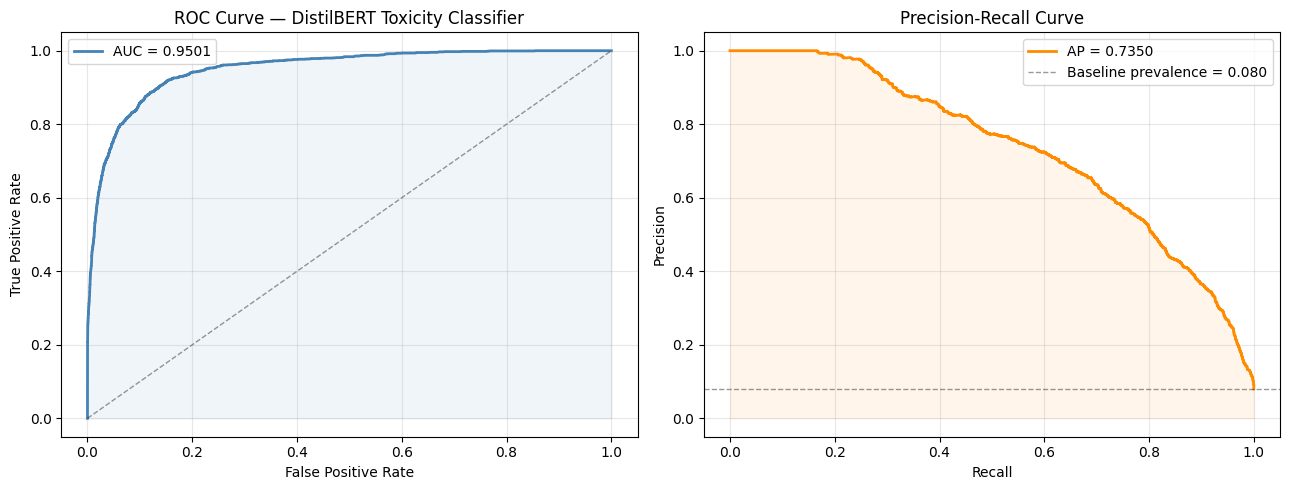

In [17]:
fpr_vals, tpr_vals, _  = roc_curve(labels, probs)
prec_vals, rec_vals, _ = precision_recall_curve(labels, probs)
auc_val = roc_auc_score(labels, probs)
ap_val  = average_precision_score(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC ---
axes[0].plot(fpr_vals, tpr_vals, color='steelblue', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].fill_between(fpr_vals, tpr_vals, alpha=0.08, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — DistilBERT Toxicity Classifier')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Precision-Recall ---
axes[1].plot(rec_vals, prec_vals, color='darkorange', lw=2, label=f'AP = {ap_val:.4f}')
axes[1].axhline(
    labels.mean(), color='k', linestyle='--', lw=1, alpha=0.4,
    label=f'Baseline prevalence = {labels.mean():.3f}'
)
axes[1].fill_between(rec_vals, prec_vals, alpha=0.08, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
# Cell 17 — ROC & PR curves
plt.savefig(f'{PROJECT_DIR}/part1_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

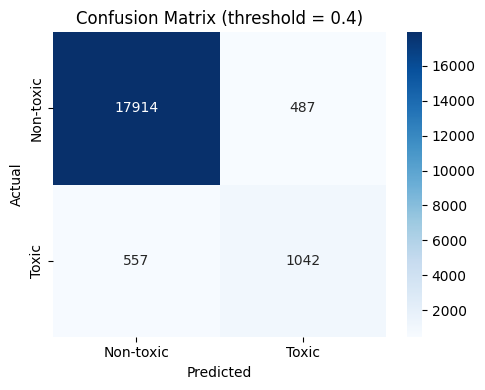

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-toxic', 'Toxic'],
    yticklabels=['Non-toxic', 'Toxic'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold = {THRESHOLD})')
plt.tight_layout()
# Cell 18 — Confusion matrix
plt.savefig(f'{PROJECT_DIR}/part1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

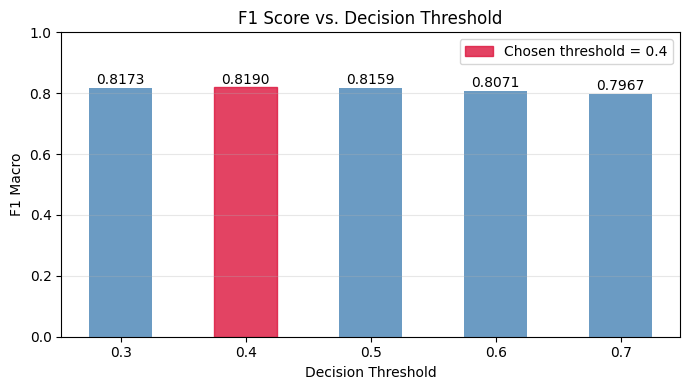

In [19]:
thresh_labels = [str(r['threshold']) for r in results]
f1_vals       = [r['f1_macro'] for r in results]
chosen_idx    = thresh_labels.index(str(THRESHOLD))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(thresh_labels, f1_vals, color='steelblue', alpha=0.8, width=0.5)
bars[chosen_idx].set_color('crimson')

for bar, val in zip(bars, f1_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{val:.4f}', ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Macro')
ax.set_title('F1 Score vs. Decision Threshold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.legend(handles=[bars[chosen_idx]], labels=[f'Chosen threshold = {THRESHOLD}'])
plt.tight_layout()
# Cell 19 — Threshold bar chart
plt.savefig(f'{PROJECT_DIR}/part1_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold choice and platform implications

The sweep shows F1 Macro peaks near **0.4** rather than the default 0.5.
Because the dataset is heavily imbalanced (~8% toxic), a threshold of 0.5
causes the model to under-predict the minority class — it is biased toward
predicting non-toxic simply because non-toxic examples dominate training.

**Chosen threshold: 0.4**

| Threshold | Prioritises | Trade-off |
|-----------|------------|-----------|
| 0.3 | Maximum recall — catches almost all toxicity | Many innocent users wrongly flagged |
| **0.4** | **Best macro F1 — chosen for this assignment** | Moderate false positives |
| 0.5 | Default — biased toward majority class | Misses too much genuine toxicity |
| 0.6–0.7 | High precision — rarely wrong when flagging | Misses the majority of toxic content |

**Platform implication:** Choosing 0.4 reflects a platform that treats missed
toxicity as more harmful than incorrectly flagging a clean comment. This is
appropriate for a safety-first platform. However, it increases false positives —
and as Part 2 will show, those false positives fall disproportionately on
comments associated with Black identity, making threshold choice a fairness
decision as much as an accuracy one.

In [20]:
import os

print("=" * 50)
print(f"PROJECT FOLDER: {PROJECT_DIR}")
print("=" * 50)

expected = {
    'Data splits': [
        'train_df.csv',
        'eval_df.csv',
    ],
    'Model outputs': [
        'eval_probs_part1.npy',
        'saved_model_part1/config.json',
        'saved_model_part1/tokenizer_config.json',
    ],
    'Plots': [
        'part1_roc_pr.png',
        'part1_confusion_matrix.png',
        'part1_threshold_sweep.png',
    ],
}

all_ok = True
for section, files in expected.items():
    print(f"\n{section}:")
    for f in files:
        full_path = f'{PROJECT_DIR}/{f}'
        if os.path.exists(full_path):
            size = os.path.getsize(full_path)
            size_str = f'{size/1e6:.1f} MB' if size > 1e5 else f'{size/1e3:.1f} KB'
            print(f"  [OK]      {f:45s} {size_str}")
        else:
            print(f"  [MISSING] {f}")
            all_ok = False

print()
if all_ok:
    print("All files present. Part 1 complete.")
    print("Download notebook: File → Download → Download .ipynb")
    print("Save the .ipynb into your REAI_Assignment2 folder in Drive.")
else:
    print("Some files are missing — re-run the cells marked above.")

PROJECT FOLDER: /content/drive/MyDrive/RAI_Assignment2

Data splits:
  [OK]      train_df.csv                                  45.5 MB
  [OK]      eval_df.csv                                   9.0 MB

Model outputs:
  [OK]      eval_probs_part1.npy                          80.1 KB
  [OK]      saved_model_part1/config.json                 0.6 KB
  [OK]      saved_model_part1/tokenizer_config.json       1.2 KB

Plots:
  [OK]      part1_roc_pr.png                              88.8 KB
  [OK]      part1_confusion_matrix.png                    39.6 KB
  [OK]      part1_threshold_sweep.png                     35.6 KB

All files present. Part 1 complete.
Download notebook: File → Download → Download .ipynb
Save the .ipynb into your REAI_Assignment2 folder in Drive.


In [21]:
# Final save check before ending runtime
import os

must_have = [
    'train_df.csv',
    'eval_df.csv',
    'eval_probs_part1.npy',
    'saved_model_part1/config.json',
    'saved_model_part1/model.safetensors',
    'saved_model_part1/tokenizer_config.json',
    'saved_model_part1/vocab.txt',
]

print(f"Checking {PROJECT_DIR}/\n")
all_ok = True
for f in must_have:
    path = f'{PROJECT_DIR}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f"  [OK]      {f:50s} {size:.1f} MB")
    else:
        print(f"  [MISSING] {f}  <-- RE-RUN THE SAVE CELL BEFORE ENDING")
        all_ok = False

print()
if all_ok:
    print("All files present in Drive. Safe to end runtime.")
else:
    print("Missing files detected. Do NOT end runtime yet.")

Checking /content/drive/MyDrive/RAI_Assignment2/

  [OK]      train_df.csv                                       45.5 MB
  [OK]      eval_df.csv                                        9.0 MB
  [OK]      eval_probs_part1.npy                               0.1 MB
  [OK]      saved_model_part1/config.json                      0.0 MB
  [OK]      saved_model_part1/model.safetensors                267.8 MB
  [OK]      saved_model_part1/tokenizer_config.json            0.0 MB
  [OK]      saved_model_part1/vocab.txt                        0.2 MB

All files present in Drive. Safe to end runtime.
